# Malaria cases in africa
 Data analysis investigation - Mark Andrews | partner: Tyler hann | 2DGT20

In [1]:
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
df = pd.read_excel('DatasetAfricaMalaria.xlsx')

# Introduction
## Dataset overview
#### This investigation looks into the correlation between reported cases of malaria across Africa and access to essential healthcare, specifically sanitation and drinking water services. It investigates whether improvements in access to clean drinking water and sanitation are associated with changes in the number of reported malaria cases over time. If a relationship can be identified, it may provide insight into the importance of these services in decreasing the impact of malaria in Africa. The dataset has records of reported malaria cases across multiple African countires over the span of 10 years (2007 - 2017). The dataset has 595 rows across 27 columns, with multiple records of data from each year for each country.
## Provenance
#### The dataset has been provided by a data scientist called Tassawar Abbas who has shared this dataset on a reliable data site known as kaggle where it has the highest usability rating. The dataset provides a multi-dimensional view of the malaria epidemic in Africa, tracking critical health, environmental, and demographic metrics over a decade (2007–2017). It is a vital resource for researchers, epidemiologists, and data scientists looking to analyze the correlations between public health interventions, basic infrastructure, and malaria prevalence. 

# Research question and Hypothesis
#### Research Question: Is there a relationship between malaria cases and access to essential health services across countries? Hypothesis: Over time, both the average number of reported malaria cases and the average level of essential health services will increase. This is because population growth may lead to more reported malaria cases while also increasing demand for healthcare services. Ethical considerations: The investigation will use public available data, meaning no personal information or direct participation from individuals is involved. Sources will be referenced for honesty and reliability. Data will also be interpreted carefully so there is no misleading conclusions or assumptions about countries being studied.
## Initial inspection

## Cleaning decisions
#### Removing completely empty rows removed rows where every value in the row was missing. These rows contained no useful information and could not contribute to the analysis. Removing them reduced unnecessary data and ensured that only observations with at least some valid information were included in the dataset. This improved the overall quality of the dataset and prevented blank rows from affecting calculations.
    df = df.dropna(how='all')
#### Identifying missing values was used to determine how many missing values were present in each column of the dataset. Although it did not directly modify the data, it allowed the dataset to be assessed for completeness and helped identify whether further cleaning was required. Understanding the extent of missing data is important because large numbers of null values can reduce the accuracy and reliability of statistical analyses.
    df.isnull().sum()
#### The next decision is removing null values and 0 values from the malaria column. Rows with missing values in the "Malaria cases reported" column were removed because this variable was central to the investigation. Missing malaria case values would make it impossible to calculate meaningful averages or identify trends over time. By removing these records, the analysis was based only on observations where the outcome variable was known, increasing the validity of the results. Rows where the number of reported malaria cases was recorded as zero were removed from the analysis. In this dataset, zero values may not necessarily represent a true absence of malaria cases and could instead indicate incomplete reporting or missing observations. Including these values would have artificially lowered the calculated means and distorted trends over time. Removing them allowed the analysis to focus on records with reported malaria activity, resulting in a clearer representation of the data.
    df = df[df['Malaria cases reported'].notna()]
    df = df[df['Malaria cases reported'] != 0]

#### Checking for duplicate rows. Duplicate records can bias results because they give certain observations more weight than others. For example, if the same country-year entry appeared multiple times, it could inflate averages and alter trends. Checking for duplicates ensured that each observation represented a unique data point and increased confidence in the accuracy of the analysis. In this dataset, the duplicate count could then be used to determine whether duplicate removal was necessary.
    df[df.duplicated(keep=False)]
    df.duplicated().sum()

#### Finally, Investigating potential outliers, as they can impact the distribution of malaria cases, including the mean, standard deviation, minimum value, maximum value, and quartiles. Examining these statistics helped identify potential outliers, such as countries with exceptionally high numbers of reported cases. Recognising outliers is important because they can strongly influence measures such as the mean and affect the appearance of graphs. Understanding their presence allowed the results to be interpreted more carefully and transparently.
    print(df['Malaria cases reported'].describe())

In [14]:
# remove duplicates and null values
df = df.dropna(how='all')
df.isnull().sum()

# remove rows where 'Malaria cases reported' is null or zero
df = df[df['Malaria cases reported'].notna()]
df = df[df['Malaria cases reported'] != 0]

# check for duplicates
df[df.duplicated(keep=False)]
df.duplicated().sum()

# check for outliers in the 'Malaria cases reported' column
print(df['Malaria cases reported'].describe())



count    4.700000e+02
mean     1.250174e+06
std      2.323952e+06
min      1.000000e+00
25%      1.984100e+04
50%      2.755410e+05
75%      1.500980e+06
max      1.682113e+07
Name: Malaria cases reported, dtype: float64


# Exploratory Analysis
(talk about stuff here)
## Visualisation plan

## Partner contribution - Tyler Hann
#### Tyler found that the exploratory analysis identified several important patterns in the malaria dataset across African countries between 2007 and 2017. A strong positive relationship was observed between population at risk and reported malaria cases. Countries with larger populations at risk generally reported higher numbers of malaria cases, indicating that total case burden tends to increase as the number of people exposed to malaria increases. However, considerable variation was present at similar population levels, suggesting that population size alone does not determine malaria outcomes. When total population and total malaria cases were compared over time, both variables increased steadily throughout the study period. This trend suggests that overall population growth was accompanied by an increase in the total number of reported malaria cases. The data did not show evidence that larger populations experienced lower overall malaria burdens.

#### An average health access score was created using available water and sanitation indicators to investigate whether improved access to basic services was associated with lower malaria cases. Health access generally improved over the study period, indicating progress in access to water and sanitation infrastructure. However, malaria cases also increased during the same period. This suggests that improvements in general service access alone were not associated with reductions in total malaria case numbers within this dataset. The findings indicate that malaria transmission is influenced by multiple factors beyond population size and access to basic services. Variables such as climate conditions, mosquito habitats, disease prevention programs, healthcare quality, and socioeconomic conditions may also contribute significantly to malaria outcomes. Overall, the exploratory analysis found that higher populations tended to be associated with higher total malaria case counts, while improvements in health access did not correspond with a clear reduction in malaria cases. These results suggest that the original hypothesis was not strongly supported by the available data and that further investigation using additional variables would be required to better understand the factors affecting malaria prevalence.

#### Additionally, Tyler also created the health columns list used in multiple of our findings:
    health_cols = [
       'People using safely managed drinking water services (% of population)',
      'People using safely managed sanitation services (% of population)',
      'People using at least basic drinking water services (% of population)',
      'People using at least basic sanitation services (% of population)'
    ]

count    5.500000e+02
mean     1.068330e+06
std      2.192802e+06
min      0.000000e+00
25%      2.211750e+03
50%      1.130260e+05
75%      1.154808e+06
max      1.682113e+07
Name: Malaria cases reported, dtype: float64


,Health_access_avg,Malaria cases reported
Year,,
2007,46.44,202046.82
2008,47.10,190167.48
2009,47.76,288292.32
2010,48.42,443695.20
2011,48.61,460057.30
2012,49.23,794384.42
2013,49.84,943499.18
2014,50.43,1540576.28
2015,51.03,1859370.52


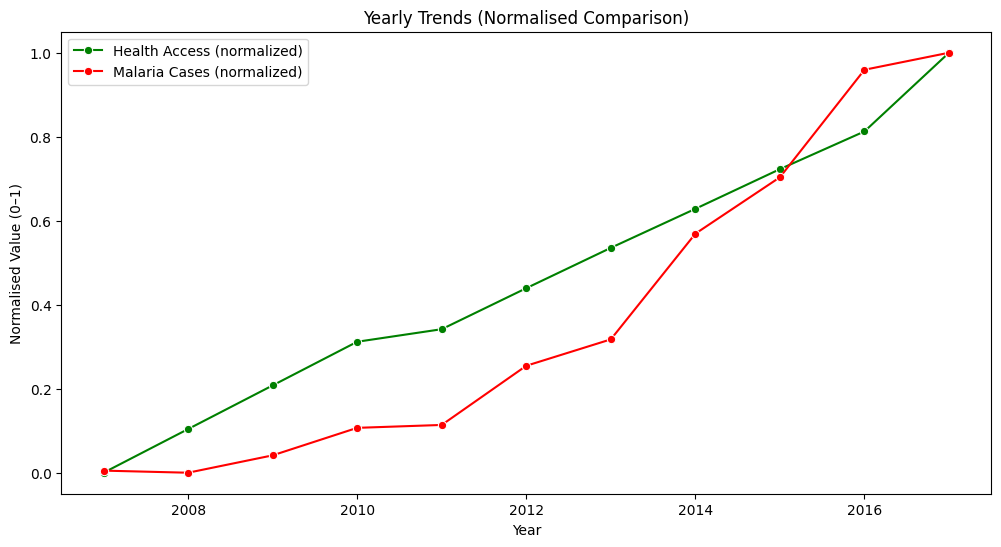

In [13]:
df = pd.read_excel('DatasetAfricaMalaria.xlsx')

# Remove Rows with missing values
df = df.dropna(how='all')

# See missing values
df.isnull().sum()

# See Duplicates and remove them
df[df.duplicated(keep=False)]

# Formatting/categorical data
df['Country Name'] = df['Country Name'].astype(str).str.strip().str.lower()
df['Country Name'].value_counts().head(10)

# Outliers
print(df['Malaria cases reported'].describe())

# Creating a "Storage" for all health columns/data
health_cols = [
    'People using safely managed drinking water services (% of population)',
    'People using safely managed sanitation services (% of population)',
    'People using at least basic drinking water services (% of population)',
    'People using at least basic sanitation services (% of population)'
]

# Average health-access score
df['Health_access_avg'] = df[health_cols].mean(axis=1)

# Yearly mean table (rounded)
yearly = df.groupby('Year')[['Health_access_avg','Malaria cases reported']].mean().round(2)

# Styled display: green = better access; red = higher cases
display(yearly)

yearly_norm = yearly.copy()

yearly_norm['Health_access_avg'] = (
    yearly['Health_access_avg'] - yearly['Health_access_avg'].min()
) / (yearly['Health_access_avg'].max() - yearly['Health_access_avg'].min()
)

yearly_norm['Malaria cases reported'] = (
    yearly_norm['Malaria cases reported'] - yearly_norm['Malaria cases reported'].min()
) / (
    yearly_norm['Malaria cases reported'].max() - yearly_norm['Malaria cases reported'].min()
)
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=yearly_norm,
    x=yearly_norm.index,
    y='Health_access_avg',
    marker='o',
    label='Health Access (normalized)',
    color='green'
)

sns.lineplot(
    data=yearly_norm,
    x=yearly_norm.index,
    y='Malaria cases reported',
    marker='o',
    label='Malaria Cases (normalized)',
    color='red'
)

plt.title('Yearly Trends (Normalised Comparison)')
plt.xlabel('Year')
plt.ylabel('Normalised Value (0–1)')
plt.legend()
plt.show()



# Analysis and Visualisation 
## Graph 1 - line graph
#### The line graph represents the mean number of malaria cases reported each year from 2007 to 2017. The x-axis shows the years included in the dataset, while the y-axis shows the average number of malaria cases reported across the countries studied. By connecting the data points, the graph makes it easier to observe how malaria cases changed over time and identify overall trends in the data.
#### The graph shows that the mean number of malaria cases reported generally increased throughout the period. There is a small decrease between 2007 and 2008, followed by a gradual increase over the next few years. After approximately 2012, the line becomes noticeably steeper, indicating that the average number of reported malaria cases began increasing at a faster rate. The largest increases occur during the later years of the dataset, particularly between 2013 and 2016.
#### This pattern suggests that the relationship between year and mean malaria cases is unlikely to be perfectly linear. In a linear relationship, the number of cases would increase by approximately the same amount each year, producing a straight line with a constant slope. Instead, the graph shows that the rate of increase itself changes over time, which is more consistent with an exponential trend where growth accelerates. Therefore, while a linear trendline can summarise the overall upward direction of the data, an exponential model may provide a better representation of the pattern observed.
#### However, the graph only shows changes in the mean number of reported malaria cases and does not explain the reasons behind these changes. The increase may reflect genuine rises in malaria incidence, but it could also be influenced by factors such as improvements in reporting systems, population growth, increased access to healthcare, or changes in data collection practices. As a result, the graph is useful for identifying trends over time, but additional analysis is required to determine the underlying causes of the observed increase.
## Graph 2 - scatterplot graph
#### The scatterplot represents the mean number of malaria cases reported for each year in the dataset. Each point corresponds to a single year, with its position on the x-axis showing the year and its position on the y-axis showing the average number of malaria cases reported across the countries included in the dataset. This graph allows the overall pattern of change in malaria cases over time to be observed without connecting the data points directly.
#### The graph shows a clear upward trend, indicating that the mean number of reported malaria cases generally increased throughout the period studied. The points are relatively close together in the earlier years, suggesting smaller changes in the mean number of cases. However, from around 2012 onwards, the points become increasingly spread out vertically, showing that the increases in reported cases became larger over time. This suggests that the relationship between year and mean malaria cases may not be linear, as the rate of increase appears to accelerate rather than remain constant.
#### While the scatterplot demonstrates a positive association between year and malaria cases, it does not explain why this increase occurred. The observed trend could be influenced by factors such as improved reporting systems, population growth, changes in data collection practices, or genuine increases in malaria incidence. Therefore, the graph is useful for identifying patterns and trends, but further analysis is required to determine the underlying causes of the increase.
## Table
#### The table presents the mean number of malaria cases reported and the mean essential health services score for each year included in the dataset. By summarising the data into yearly averages, the table allows changes in both variables to be compared directly over time without the influence of individual country-level fluctuations.
#### The table shows that the mean number of malaria cases reported generally increased throughout the study period. The increases are relatively small in the earlier years but become more substantial in the later years, particularly after approximately 2012. This supports the pattern observed in the line graph, where the growth in reported malaria cases appears to accelerate over time rather than increase at a constant rate.

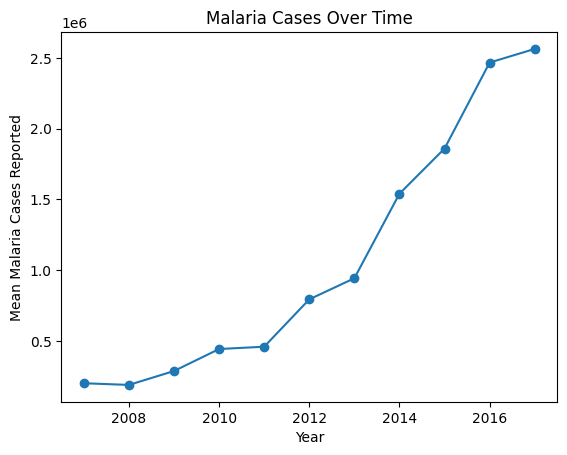

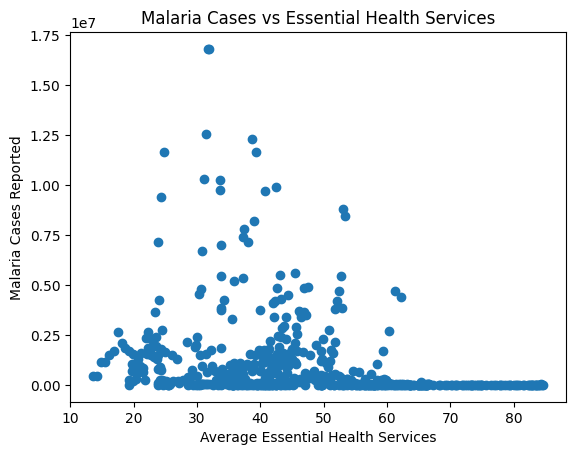

      Mean Malaria Cases Reported  Mean Essential Health Services
Year                                                             
2007                    202046.82                       46.439371
2008                    190167.48                       47.102987
2009                    288292.32                       47.760079
2010                    443695.20                       48.421289
2011                    460057.30                       48.614120
2012                    794384.42                       49.230463
2013                    943499.18                       49.840957
2014                   1540576.28                       50.431435
2015                   1859370.52                       51.026775
2016                   2466616.36                       51.604877
2017                   2562925.10                       52.789920


In [4]:
health_cols = [
    'People using safely managed drinking water services (% of population)',
    'People using safely managed sanitation services (% of population)',
    'People using at least basic drinking water services (% of population)',
    'People using at least basic sanitation services (% of population)'
]

malaria_by_year = df.groupby('Year')['Malaria cases reported'].mean()
plt.plot(malaria_by_year.index, malaria_by_year.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Mean Malaria Cases Reported')
plt.title('Malaria Cases Over Time')
plt.show()

health_average = df[health_cols].mean(axis=1)
plt.scatter(health_average, df['Malaria cases reported'])
plt.xlabel('Average Essential Health Services')
plt.ylabel('Malaria Cases Reported')
plt.title('Malaria Cases vs Essential Health Services')
plt.show()



# calculate the average essential health services score for each row
df['Health Average'] = df[health_cols].mean(axis=1)

# create a summary table by year
summary_table = df.groupby('Year').agg({
    'Malaria cases reported': 'mean',
    'Health Average': 'mean'
})

# rename the columns
summary_table = summary_table.rename(columns={
    'Malaria cases reported': 'Mean Malaria Cases Reported',
    'Health Average': 'Mean Essential Health Services'
})

print(summary_table)

# Hypothesis assessment

#### The hypothesis predicted that, over time, both the mean number of reported malaria cases and the level of essential health services would increase. The results generally support this prediction.

#### The first graph shows that the mean number of malaria cases reported increased between 2007 and 2017. Although there is a slight decrease between 2007 and 2008, the overall trend is positive. The increase becomes much steeper after approximately 2012, suggesting that malaria cases increased at an accelerating rate rather than by a constant amount each year. This indicates that an exponential model is likely to describe the pattern more accurately than a linear model.

#### The second graph compares malaria cases with the average essential health services score across countries. While the scatterplot does not show a strong linear relationship, it demonstrates that countries with similar health service scores can have very different numbers of reported malaria cases. This suggests that access to essential health services alone does not explain the variation in malaria cases. Other factors, including climate, mosquito populations, economic conditions, population size and disease reporting systems, are also likely to influence the number of reported cases.

#### With this in mind, the hypothesis is partially supported. The data support the prediction that both malaria cases and essential health services generally increased over time. However, the relationship between malaria cases and essential health services is much weaker than expected, indicating that healthcare access is only one of several factors affecting malaria prevalence.

# Conclusion
#### The investigation aimed to determine whether there is a relationship between malaria cases and access to essential health services across African countries. The results show that mean malaria cases reported generally increased between 2007 and 2017, while average essential health services also improved over the same period.

#### However, improvements in health services might be expected to reduce malaria cases, the scatterplot graph shows that the relationship between these two variables is not strong. Countries with similar health service scores often reported very different numbers of malaria cases, suggesting that healthcare access alone cannot explain malaria prevalence. The first graph also indicates that malaria cases increased at an accelerating rate over time, meaning that an exponential model provides a better description of the data than a linear model. This trend may reflect population growth, improved disease reporting, changes in surveillance systems, or genuine increases in malaria transmission.

#### Overall, the investigation concludes that there is only a weak relationship between access to essential health services and reported malaria cases. Malaria prevalence is influenced by many interacting factors, meaning that improvements in healthcare alone are not sufficient to explain the patterns observed in the dataset.

# Reflection
## My contribution

## My analytical decisions

## Ethical considerations

## Limitations

#### limitations: only covers 10 years

## Acknowledgement of generative AI
